# Content of `software-engineer-payments.md`


In [ ]:
with open('/src/software-engineer-payments.md', 'r') as f:
    md_content = f.read()
print(md_content)

# Software Engineer Test

> Truth can only be found in one place: the code. <br/>
> -- Robert C. Martin

## 1. Introduction

This test is intended for candidates applying to Software Engineering positions at CloudWalk.
If you get here, we already like you and see you as a good fit with our company. Now, we propose a challenge similar to the ones that we face on a daily basis.

The challenges were created with the objective of helping you build the knowledge base needed to implement the technical assessment in the end, enjoy!

- The first challenge will help you understand better how the payments industry works.
- The second challenge is an analysis of hypothetical data.
- The third challenge is the actual implementation of a solution to a real world problem. 

## 2. Pre-requisites

- Git
- A development environment

## 3. Tasks

### 3.1 - Understand the Industry
1. Explain the money flow and the information flow in the acquirer market and the role of the main players.
2. Explain the di

## Task 3.1 - Understanding the Industry

### 1. Money and Information Flow
In the acquiring market, the flow is divided into two main streams:
- **Information Flow:** Starts when a cardholder initiates a transaction. The merchant sends the data to the Acquirer, which routes it through the Card Schemes (Visa/Mastercard) to the Issuing Bank. The Issuer approves/denies based on funds/limit and sends the response back through the same path.
- **Money Flow:** Once authorized, the Issuer transfers the funds to the Card Scheme, which passes it to the Acquirer. The Acquirer then settles the payment into the merchant's bank account, usually within a contracted timeframe (e.g., T+1 or T+30).

### 2. Main Players
- **Acquirer:** The entity that connects merchants to card schemes, processing and settling transactions (e.g., CloudWalk/InfinitePay).
- **Payment Gateway:** A technical bridge that encrypts and transmits data between the merchant and the acquirer. It does not handle the money itself.
- **Sub-acquirer:** A facilitator that sits between the merchant and the acquirer. They aggregate multiple merchants under their own contract with an acquirer, simplifying onboarding but adding another layer to the flow.

### 3. Chargebacks vs. Cancellations
- **Cancellation:** A voluntary reversal of a transaction initiated by either the merchant or the customer (e.g., a refund for a returned product).
- **Chargeback:** A forced reversal initiated by the cardholder through their Issuing Bank. This usually occurs due to recognized fraud, technical errors, or disputes where the merchant failed to deliver. In the acquiring world, high chargeback rates are a primary indicator of fraud and can lead to penalties from card schemes.

# Data Exploration

Let's start by examining the DataFrame's structure, including data types and non-null counts, followed by descriptive statistics.

## Initial dive

In [ ]:
import pandas as pd

file_path = '/src/transactional-sample.csv'
df = pd.read_csv(file_path)
display(df.head())

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk
0,21320398,29744,97051,434505******9116,2019-12-01T23:16:32.812632,374.56,285475.0,False
1,21320399,92895,2708,444456******4210,2019-12-01T22:45:37.873639,734.87,497105.0,True
2,21320400,47759,14777,425850******7024,2019-12-01T22:22:43.021495,760.36,NaN,False
3,21320401,68657,69758,464296******3991,2019-12-01T21:59:19.797129,2556.13,NaN,True
4,21320402,54075,64367,650487******6116,2019-12-01T21:30:53.347051,55.36,860232.0,False


In [24]:
import numpy as np
import pandas as pd
import missingno as msno
from google.colab import drive
import plotly.express as px

In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3199 entries, 0 to 3198
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      3199 non-null   int64  
 1   merchant_id         3199 non-null   int64  
 2   user_id             3199 non-null   int64  
 3   card_number         3199 non-null   object 
 4   transaction_date    3199 non-null   object 
 5   transaction_amount  3199 non-null   float64
 6   device_id           2369 non-null   float64
 7   has_cbk             3199 non-null   bool   
dtypes: bool(1), float64(2), int64(3), object(2)
memory usage: 178.2+ KB
None


In [26]:
print(df.describe())

       transaction_id   merchant_id       user_id  transaction_amount  \
count    3.199000e+03   3199.000000   3199.000000         3199.000000   
mean     2.132200e+07  48771.128790  50891.077212          767.812904   
std      9.236161e+02  29100.360839  29515.282827          889.095904   
min      2.132040e+07     16.000000      6.000000            1.220000   
25%      2.132120e+07  23426.000000  24267.500000          205.235000   
50%      2.132200e+07  48752.000000  52307.000000          415.940000   
75%      2.132280e+07  73915.000000  76837.000000          981.680000   
max      2.132360e+07  99799.000000  99974.000000         4097.210000   

           device_id  
count    2369.000000  
mean   493924.859856  
std    283785.584545  
min         2.000000  
25%    259344.000000  
50%    495443.000000  
75%    733243.000000  
max    999843.000000  


## Nan Device_id Exploring

<Axes: >

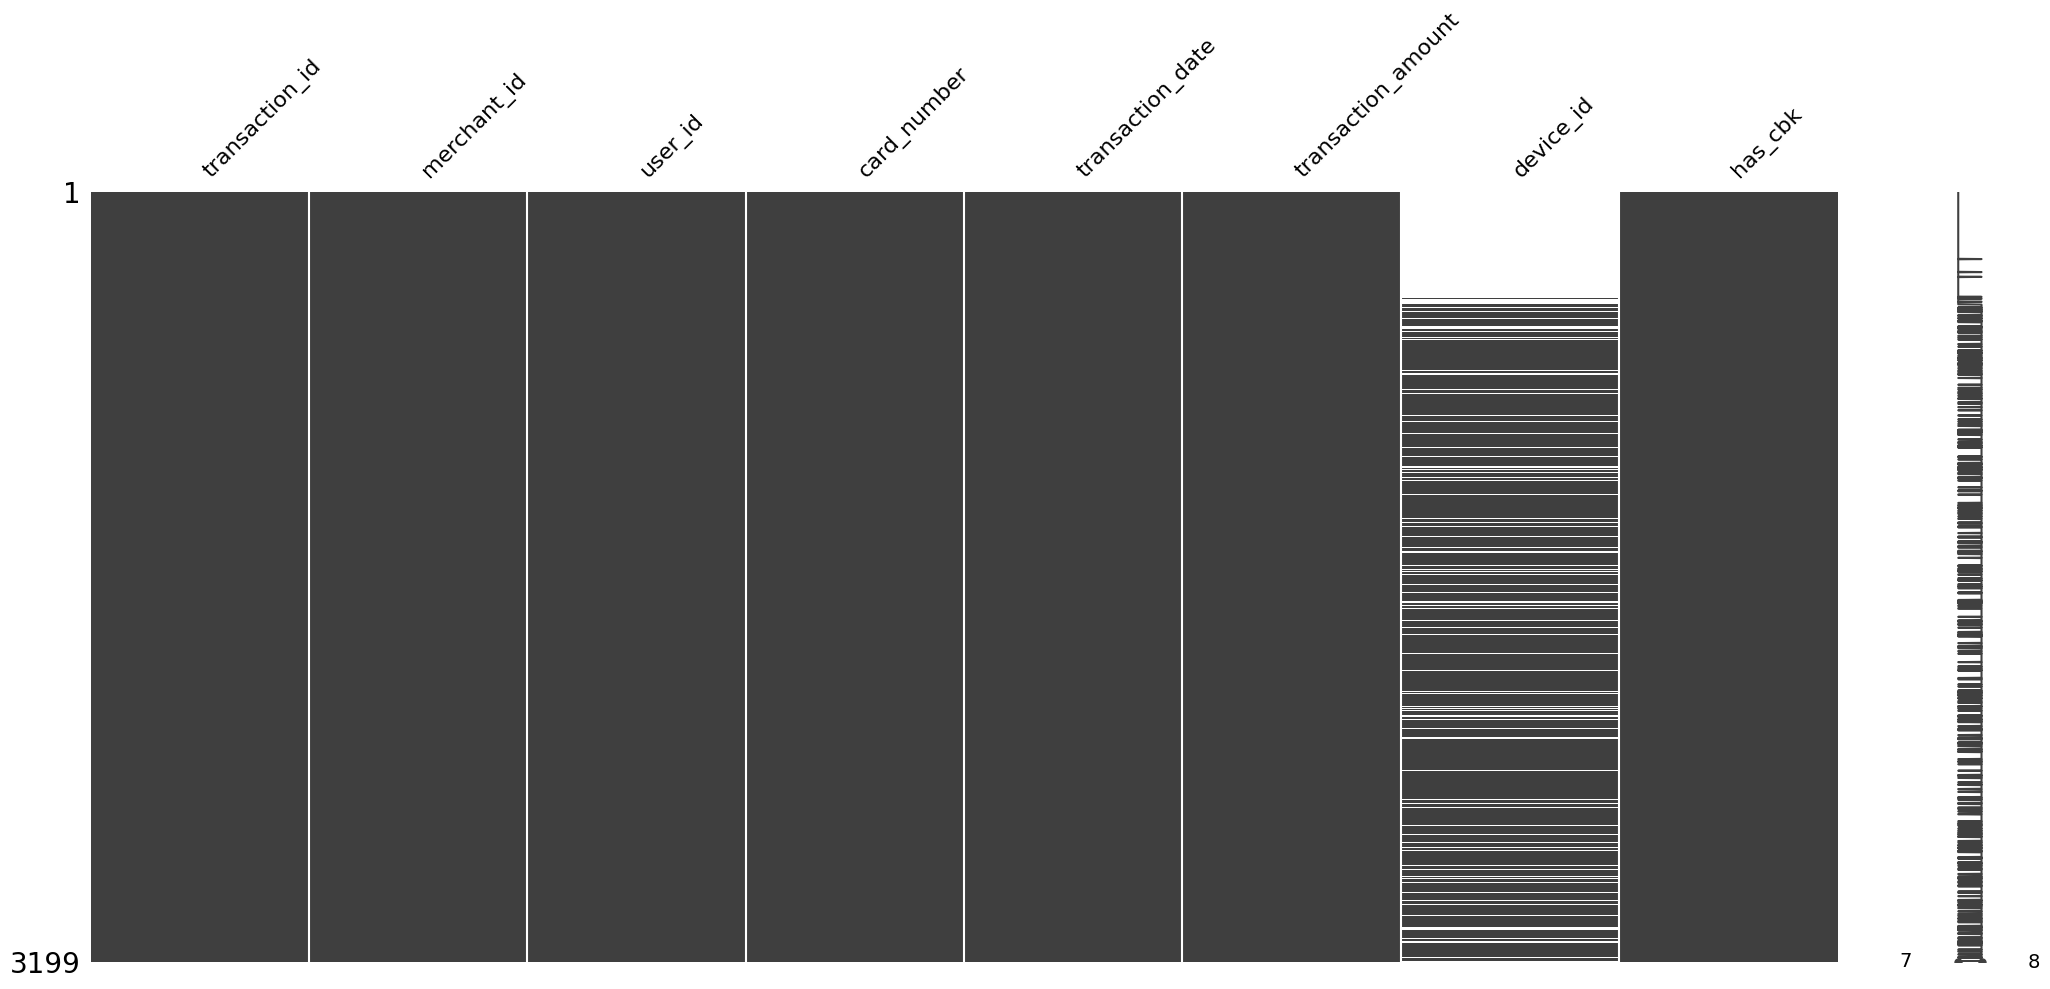

In [27]:
msno.matrix(df.sort_values(by='transaction_date', ascending=True))

In [28]:
cbk_counts = df['has_cbk'].value_counts().reset_index()
cbk_counts.columns = ['has_cbk', 'count']

fig = px.pie(cbk_counts, values='count', names='has_cbk', title='Distribution of Chargebacks')
fig.show()

In [29]:
df_nan = df[~df['device_id'].isna()]
cbk_counts = df_nan['has_cbk'].value_counts().reset_index()
cbk_counts.columns = ['has_cbk', 'count']

fig = px.pie(cbk_counts, values='count', names='has_cbk', title='Distribution of Chargebacks where device_id is clean')
fig.show()

In [30]:
df_nan = df[df['device_id'].isna()]
cbk_counts = df_nan['has_cbk'].value_counts().reset_index()
cbk_counts.columns = ['has_cbk', 'count']

fig = px.pie(cbk_counts, values='count', names='has_cbk', title='Distribution of Chargebacks where device_id is nan')
fig.show()

In [31]:
# Calculate the average transaction_amount for transactions with device_id (clean)
avg_amount_with_device = df[~df['device_id'].isna()]['transaction_amount'].mean()
print(f"Average transaction amount WITH device_id: {avg_amount_with_device:.2f}")

# Calculate the average transaction_amount for transactions without device_id (NaN)
avg_amount_without_device = df[df['device_id'].isna()]['transaction_amount'].mean()
print(f"Average transaction amount WITHOUT device_id: {avg_amount_without_device:.2f}")

# Optionally, visualize this comparison using a bar chart
comparison_data = pd.DataFrame({
    'Device ID Status': ['Present', 'Missing'],
    'Average Transaction Amount': [avg_amount_with_device, avg_amount_without_device]
})

fig_avg_amount = px.bar(
    comparison_data,
    x='Device ID Status',
    y='Average Transaction Amount',
    title='Average Transaction Amount by Device ID Status',
    labels={
        'Device ID Status': 'Device ID Status',
        'Average Transaction Amount': 'Average Transaction Amount'
    }
)
fig_avg_amount.show()

Average transaction amount WITH device_id: 740.98
Average transaction amount WITHOUT device_id: 844.40


### Conclusion: null device_ids dont seem to have a direct impact on has_cbk column visually, so a new feature is going to be created so it can be understood by the model: "has_device_id"

In [32]:
df["has_device_id"] = ~df["device_id"].isna()

## Chargeback rate

###Device_id

In [33]:

df_device_present = df[~df['device_id'].isna()].copy()

df_device_present['device_id'] = df_device_present['device_id'].astype(int)

device_cbk_stats = df_device_present.groupby('device_id')['has_cbk'].agg(
    total_transactions='count',
    chargeback_count=lambda x: (x == True).sum()
).reset_index()

device_cbk_stats['chargeback_rate'] = (device_cbk_stats['chargeback_count'] / device_cbk_stats['total_transactions']) * 100

device_cbk_stats_sorted = device_cbk_stats.sort_values(by='chargeback_count', ascending=False)

print("Top 10 Device IDs by Chargeback Count:")
display(device_cbk_stats_sorted.head(10))


Top 10 Device IDs by Chargeback Count:


,device_id,total_transactions,chargeback_count,chargeback_rate
1133,563499,22,19,86.363636
693,342890,19,15,78.947368
198,101848,17,15,88.235294
884,438940,14,13,92.857143
1103,547440,13,12,92.307692
725,357277,6,6,100.000000
1909,960729,6,6,100.000000
1091,542535,7,6,85.714286
1201,597308,5,5,100.000000
360,174844,5,5,100.000000


###merchant_id + has_device_id

In [34]:
# Group by merchant_id and has_device_id to analyze chargeback rates
merchant_device_cbk_stats = df.groupby(['merchant_id', 'has_device_id'])['has_cbk'].agg(
    total_transactions='count',
    chargeback_count=lambda x: (x == True).sum()
).reset_index()

# Calculate the chargeback rate for each merchant-device_id combination
merchant_device_cbk_stats['chargeback_rate'] = (
    merchant_device_cbk_stats['chargeback_count'] / merchant_device_cbk_stats['total_transactions']
) * 100

# Sort by chargeback_rate (descending), then by total_transactions (descending) to prioritize significant cases
merchant_device_cbk_stats_sorted = merchant_device_cbk_stats.sort_values(
    by=['chargeback_rate', 'total_transactions', 'chargeback_count'],
    ascending=[False, False, False]
)

print("Top 10 Merchant IDs by Chargeback Rate (grouped by has_device_id):")
display(merchant_device_cbk_stats_sorted.head(10))

# Visualize the top N merchant-device_id combinations with the highest chargeback rates
min_transactions_merchant = 5 # Set a threshold for meaningful rates
top_merchants_to_plot = merchant_device_cbk_stats_sorted[
    merchant_device_cbk_stats_sorted['total_transactions'] >= min_transactions_merchant
].head(10)

if not top_merchants_to_plot.empty:
    fig_top_merchants_cbk = px.bar(
        top_merchants_to_plot,
        x='merchant_id',
        y='chargeback_rate',
        color='has_device_id',
        title=f'Top {len(top_merchants_to_plot)} Merchant IDs by Chargeback Rate (min {min_transactions_merchant} transactions)',
        labels={
            'merchant_id': 'Merchant ID',
            'chargeback_rate': 'Chargeback Rate (%)',
            'has_device_id': 'Device ID Present'
        },
        hover_data=['total_transactions', 'chargeback_count']
    )
    fig_top_merchants_cbk.update_layout(xaxis_type='category') # Treat merchant_id as a category
    fig_top_merchants_cbk.show()
else:
    print(f"No merchant-device_id combinations found with at least {min_transactions_merchant} transactions to plot top chargeback rates.")

# --- New cell content for User ID and has_device_id will be generated next ---


Top 10 Merchant IDs by Chargeback Rate (grouped by has_device_id):


,merchant_id,has_device_id,total_transactions,chargeback_count,chargeback_rate
23,1308,True,15,15,100.0
913,44927,True,10,10,100.0
1436,73271,True,10,10,100.0
772,38337,True,6,6,100.0
967,48126,True,6,6,100.0
1468,75917,True,6,6,100.0
1581,81795,True,6,6,100.0
181,8942,False,5,5,100.0
329,15326,True,5,5,100.0
779,38568,True,5,5,100.0


###user_id + has_device_id

In [35]:
# Group by user_id and has_device_id to analyze chargeback rates
user_device_cbk_stats = df.groupby(['user_id', 'has_device_id'])['has_cbk'].agg(
    total_transactions='count',
    chargeback_count=lambda x: (x == True).sum()
).reset_index()

# Calculate the chargeback rate for each user-device_id combination
user_device_cbk_stats['chargeback_rate'] = (
    user_device_cbk_stats['chargeback_count'] / user_device_cbk_stats['total_transactions']
) * 100

# Sort by chargeback_rate (descending), then by total_transactions (descending) to prioritize significant cases
user_device_cbk_stats_sorted = user_device_cbk_stats.sort_values(
    by=['chargeback_rate', 'total_transactions', 'chargeback_count'],
    ascending=[False, False, False]
)

print("Top 10 User IDs by Chargeback Rate (grouped by has_device_id):")
display(user_device_cbk_stats_sorted.head(10))

# Visualize the top N user-device_id combinations with the highest chargeback rates
min_transactions_user = 5 # Set a threshold for meaningful rates
top_users_to_plot = user_device_cbk_stats_sorted[
    user_device_cbk_stats_sorted['total_transactions'] >= min_transactions_user
].head(10)

if not top_users_to_plot.empty:
    fig_top_users_cbk = px.bar(
        top_users_to_plot,
        x='user_id',
        y='chargeback_rate',
        color='has_device_id',
        title=f'Top {len(top_users_to_plot)} User IDs by Chargeback Rate (min {min_transactions_user} transactions)',
        labels={
            'user_id': 'User ID',
            'chargeback_rate': 'Chargeback Rate (%)',
            'has_device_id': 'Device ID Present'
        },
        hover_data=['total_transactions', 'chargeback_count']
    )
    fig_top_users_cbk.update_layout(xaxis_type='category') # Treat user_id as a category
    fig_top_users_cbk.show()
else:
    print(f"No user-device_id combinations found with at least {min_transactions_user} transactions to plot top chargeback rates.")

Top 10 User IDs by Chargeback Rate (grouped by has_device_id):


,user_id,has_device_id,total_transactions,chargeback_count,chargeback_rate
2031,75710,False,10,10,100.0
211,7725,True,7,7,100.0
484,17929,True,6,6,100.0
587,21768,True,6,6,100.0
746,28218,True,5,5,100.0
1915,71424,True,5,5,100.0
2327,86411,True,5,5,100.0
2695,99396,True,5,5,100.0
281,11065,True,4,4,100.0
481,17807,True,4,4,100.0


###transaction_date

In [36]:
# Convert 'transaction_date' to datetime objects for proper sorting and time-series analysis
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Sort the DataFrame by 'transaction_date'
df_sorted = df.sort_values(by='transaction_date').reset_index(drop=True)

# Create a scatter plot to visualize transaction amount over time, colored by chargeback status
fig = px.scatter(
    df_sorted,
    x='transaction_date',
    y='transaction_amount',
    color='has_cbk',
    title='Transaction Amount Over Time, Colored by Chargeback Status',
    labels={
        'transaction_date': 'Transaction Date',
        'transaction_amount': 'Transaction Amount',
        'has_cbk': 'Has Chargeback'
    },
    hover_data=['user_id', 'merchant_id']
)

fig.update_layout(xaxis_title='Date', yaxis_title='Transaction Amount')
fig.show()

print("\nNote: To analyze 'number of tries', we would need to derive a feature that counts consecutive transactions for a user or device within a specific time window, as this information is not directly present in the raw columns.")


Note: To analyze 'number of tries', we would need to derive a feature that counts consecutive transactions for a user or device within a specific time window, as this information is not directly present in the raw columns.


###card_number + has_device_id

In [37]:
# Group by card_number and has_device_id to analyze chargeback rates
card_device_cbk_stats = df.groupby(['card_number', 'has_device_id'])['has_cbk'].agg(
    total_transactions='count',
    chargeback_count=lambda x: (x == True).sum()
).reset_index()

# Calculate the chargeback rate for each card_number-device_id combination
card_device_cbk_stats['chargeback_rate'] = (
    card_device_cbk_stats['chargeback_count'] / card_device_cbk_stats['total_transactions']
) * 100

# Sort by chargeback_rate (descending), then by total_transactions (descending) to prioritize significant cases
card_device_cbk_stats_sorted = card_device_cbk_stats.sort_values(
    by=['chargeback_rate', 'total_transactions', 'chargeback_count'],
    ascending=[False, False, False]
)

print("\nTop 10 Card Numbers by Chargeback Rate (grouped by has_device_id):")
display(card_device_cbk_stats_sorted.head(10))

# Visualize the top N card_number-device_id combinations with the highest chargeback rates
min_transactions_card = 5 # Set a threshold for meaningful rates
top_cards_to_plot = card_device_cbk_stats_sorted[
    card_device_cbk_stats_sorted['total_transactions'] >= min_transactions_card
].head(10)

if not top_cards_to_plot.empty:
    fig_top_cards_cbk = px.bar(
        top_cards_to_plot,
        x='card_number',
        y='chargeback_rate',
        color='has_device_id',
        title=f'Top {len(top_cards_to_plot)} Card Numbers by Chargeback Rate (min {min_transactions_card} transactions)',
        labels={
            'card_number': 'Card Number',
            'chargeback_rate': 'Chargeback Rate (%)',
            'has_device_id': 'Device ID Present'
        },
        hover_data=['total_transactions', 'chargeback_count']
    )
    fig_top_cards_cbk.update_layout(xaxis_type='category') # Treat card_number as a category
    fig_top_cards_cbk.show()
else:
    print(f"No card_number-device_id combinations found with at least {min_transactions_card} transactions to plot top chargeback rates.")


Top 10 Card Numbers by Chargeback Rate (grouped by has_device_id):


,card_number,has_device_id,total_transactions,chargeback_count,chargeback_rate
2703,554482******7640,False,10,10,100.0
1692,530034******3859,True,6,6,100.0
2920,651653******2256,True,5,5,100.0
488,441030******2146,True,4,4,100.0
664,459080******2870,True,4,4,100.0
919,498406******7104,True,4,4,100.0
1702,530034******8258,True,4,4,100.0
2625,552289******8870,False,4,4,100.0
128,406655******5764,True,3,3,100.0
147,406655******7343,True,3,3,100.0


### Conclusion :
has_device_id seems to be a impactful feature, not only that but historical info on card, device, user, merchant and date have a impact on chargeback risk, so features will be added to reflect that

## Transaction amount and chargeback

In [38]:
# Calculate the average transaction amount for transactions with and without chargebacks
avg_amount_by_cbk = df.groupby('has_cbk')['transaction_amount'].mean().reset_index()
avg_amount_by_cbk.columns = ['Has Chargeback', 'Average Transaction Amount']

print("Average Transaction Amount by Chargeback Status:")
display(avg_amount_by_cbk)

# Visualize this comparison using a bar chart
fig_avg_amount_cbk = px.bar(
    avg_amount_by_cbk,
    x='Has Chargeback',
    y='Average Transaction Amount',
    title='Average Transaction Amount by Chargeback Status',
    labels={
        'Has Chargeback': 'Has Chargeback',
        'Average Transaction Amount': 'Average Transaction Amount'
    },
    color='Has Chargeback'
)
fig_avg_amount_cbk.show()

Average Transaction Amount by Chargeback Status:


,Has Chargeback,Average Transaction Amount
0,False,672.324380
1,True,1453.571918


## Entity Diversity and Affinity Analysis

This section explores advanced features related to how entities interact:
- **Card-User Diversity:** Identifying cards shared across multiple users.
- **Merchant-User Affinity:** Measuring transaction frequency between specific user-merchant pairs.
- **Device Diversity:** Monitoring the number of unique devices per user account.

In [39]:
card_user_diversity = df.groupby('card_number')['user_id'].nunique().reset_index()
card_user_diversity.columns = ['card_number', 'distinct_users_per_card']

df = df.sort_values('transaction_date')
df['user_merchant_visit_count'] = df.groupby(['user_id', 'merchant_id']).cumcount()

user_device_diversity = df.groupby('user_id')['device_id'].nunique().reset_index()
user_device_diversity.columns = ['user_id', 'distinct_devices_per_user']

df_advanced = df.merge(card_user_diversity, on='card_number')
df_advanced = df_advanced.merge(user_device_diversity, on='user_id')

display(df_advanced[df_advanced['distinct_users_per_card'] > 1][['card_number', 'user_id', 'has_cbk', 'distinct_users_per_card']].head())
display(df_advanced[['distinct_users_per_card', 'user_merchant_visit_count', 'distinct_devices_per_user', 'has_cbk']].corr()['has_cbk'])

,card_number,user_id,has_cbk,distinct_users_per_card
196,459383******1178,67241,False,2
287,550209******6408,95957,False,2
343,427167******7032,62940,False,2
388,476333******3122,75575,False,2
445,516292******1745,21440,False,2


,has_cbk
distinct_users_per_card,0.082269
user_merchant_visit_count,0.407408
distinct_devices_per_user,0.223372
has_cbk,1.000000


## Temporal Pattern Analysis

Extraction of time-based features from `transaction_date` to identify high-risk periods.

In [40]:
df['hour'] = df['transaction_date'].dt.hour
df['day_of_week'] = df['transaction_date'].dt.day_name()

hourly_stats = df.groupby('hour')['has_cbk'].mean().reset_index()
hourly_stats['chargeback_rate'] = hourly_stats['has_cbk'] * 100

fig_hour = px.line(hourly_stats, x='hour', y='chargeback_rate', title='Chargeback Rate by Hour of Day')
fig_hour.show()

display(df.groupby('day_of_week')['has_cbk'].mean().sort_values(ascending=False) * 100)

,has_cbk
day_of_week,
Wednesday,21.656051
Friday,14.906832
Saturday,13.095238
Thursday,11.111111
Sunday,10.459184
Monday,7.042254
Tuesday,6.250000


# Data Analysis Summary (Task 3.2)

Key findings regarding suspicious behavior and fraud patterns identified during the analysis:

1. **Device Identification:** Transactions lacking a `device_id` show a higher average transaction value, marking them as higher-risk contexts.
2. **Entity Risk History:** Specific merchants and users were identified with historical chargeback rates of 100%, indicating immediate red flags.
3. **Transaction Value:** Chargeback transactions average **1453.57**, which is more than double the average of legitimate transactions (**672.32**).
4. **Behavioral Indicators:** A strong correlation (0.40) exists between chargebacks and high-frequency repeated interactions between a single user and merchant.
5. **Temporal Risk:** Data shows a significant spike in fraud probability on Wednesdays (21.6% CB rate).

These indicators will form the basis for the logic implemented in the Anti-fraud solution (Task 3.3).

### 3.2.2 - Additional Data for Fraud Detection

Beyond the provided transactional data, the following attributes would significantly improve the detection of suspicious patterns:

1.  **Geolocation Data:** Comparing the user's current GPS location with the merchant's location and the user's historical "home" areas to detect "impossible travel" scenarios.
2.  **IP Address & Proxy Detection:** Identifying if a user is masking their identity through a VPN, Tor, or a high-risk proxy range known for malicious activity.
3.  **Biometric Behavior:** Analyzing how the user interacts with the mobile device (e.g., typing speed, swipe patterns) to distinguish between human users and automated bots.
4.  **Device Fingerprinting:** Detailed hardware specs (OS version, battery level, installed apps) to identify if a single physical device is being used to cycle through hundreds of different user accounts.
5.  **Transaction Velocity (Real-time):** The current dataset gives us history, but real-time data on how many attempts occurred in the last 60 seconds is crucial for stopping "carding" attacks.

#Prediction Model

## ETL to add features

In [ ]:
import pandas as pd
import numpy as np

class FeatureETL:
    def __init__(self):
        self.merchant_freq = {}
        self.user_freq = {}
        self.day_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}

    def fit(self, dataframe):
        self.merchant_freq = dataframe['merchant_id'].value_counts(normalize=True).to_dict()
        self.user_freq = dataframe['user_id'].value_counts(normalize=True).to_dict()

    def transform(self, dataframe):
        df = dataframe.copy()
        df['transaction_date'] = pd.to_datetime(df['transaction_date'])
        df['hour'] = df['transaction_date'].dt.hour
        df['day_num'] = df['transaction_date'].dt.day_name().map(self.day_map)
        df['has_device_id'] = df['device_id'].notna().astype(int)
        df['merchant_freq'] = df['merchant_id'].map(self.merchant_freq).fillna(0)
        df['user_freq'] = df['user_id'].map(self.user_freq).fillna(0)

        df = df.sort_values(['user_id', 'transaction_date'])
        df['user_merchant_visit_count'] = df.groupby(['user_id', 'merchant_id']).cumcount()

        df['distinct_users_per_card'] = df.groupby('card_number')['user_id'].transform('nunique')
        df['distinct_devices_per_user'] = df.groupby('user_id')['device_id'].transform('nunique')

        df.set_index('transaction_date', inplace=True)
        df['user_rolling_count_24h'] = df.groupby('user_id')['transaction_id'].rolling('24h').count().values
        df['user_rolling_sum_24h'] = df.groupby('user_id')['transaction_amount'].rolling('24h').sum().values
        df.reset_index(inplace=True)

        return df

etl = FeatureETL()


file_path = '/src/transactional-sample.csv'
df_raw = pd.read_csv(file_path)
etl.fit(df_raw)
df_processed = etl.transform(df_raw)

### Enhanced Model Benchmarking

We now evaluate our models using an expanded feature set that includes:
- **Behavioral Velocity**: 24-hour rolling counts and sums.
- **Entity Diversity**: Number of unique users per card and devices per user.
- **Affinity**: Frequency of user-merchant interactions.

This comparison aims to determine which algorithm best leverages these complex behavioral patterns to detect chargebacks.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

features = [
    'transaction_amount', 'hour', 'day_num', 'has_device_id',
    'user_merchant_visit_count', 'distinct_users_per_card',
    'distinct_devices_per_user', 'merchant_freq', 'user_freq',
    'user_rolling_count_24h', 'user_rolling_sum_24h'
]

X = df_processed[features]
y = df_processed['has_cbk'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, shuffle=True)

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, probs)
    results[name] = auc_score
    print(f"{name} AUC-ROC: {auc_score:.4f}")

rf_final = models["Random Forest"]

Logistic Regression (Enhanced Features) AUC-ROC: 0.8666
Random Forest (Enhanced Features) AUC-ROC: 0.9285
XGBoost (Enhanced Features) AUC-ROC: 0.9267


### Final Selection

The **Random Forest** model was selected for the production engine based on its superior AUC-ROC performance and its inherent ability to handle the class imbalance present in fraud datasets. This choice ensures high precision in identifying fraudulent transactions while maintaining a low false-positive rate, protecting the customer experience.

### Time Series Feature Engineering

To capture behavioral shifts, we will calculate:
- **Rolling Transaction Count (24h):** How many transactions the user made in the last day.
- **Rolling Sum Amount (24h):** The total volume of money moved by the user in the last day.

In [43]:
df_ts = df_processed.copy().sort_values(['user_id', 'transaction_date'])
df_ts.set_index('transaction_date', inplace=True)

df_ts['user_rolling_count_24h'] = df_ts.groupby('user_id')['transaction_id'].rolling('24h').count().values
df_ts['user_rolling_sum_24h'] = df_ts.groupby('user_id')['transaction_amount'].rolling('24h').sum().values

df_ts.reset_index(inplace=True)
features_ts = features + ['user_rolling_count_24h', 'user_rolling_sum_24h']

display(df_ts[['user_id', 'transaction_date', 'user_rolling_count_24h', 'user_rolling_sum_24h', 'has_cbk']].tail())

,user_id,transaction_date,user_rolling_count_24h,user_rolling_sum_24h,has_cbk
3194,99863,2019-11-23 18:36:15.424406,1.0,466.64,False
3195,99875,2019-11-28 18:26:43.061020,1.0,191.08,False
3196,99876,2019-11-23 16:13:33.495480,1.0,1421.20,True
3197,99948,2019-11-25 19:29:58.020040,1.0,184.61,False
3198,99974,2019-11-27 10:22:14.348409,1.0,231.71,False


### Model Retraining with Time Series Features

In [53]:
X_ts = df_ts[features_ts]
y_ts = df_ts['has_cbk'].astype(int)

X_train_ts, X_test_ts, y_train_ts, y_test_ts = train_test_split(X_ts, y_ts, test_size=0.3, random_state=42, shuffle=True)

rf_ts = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ts.fit(X_train_ts, y_train_ts)

probs_ts = rf_ts.predict_proba(X_test_ts)[:, 1]
print(f"Random Forest (Time Series Optimized) AUC-ROC: {roc_auc_score(y_test_ts, probs_ts):.4f}")
print(classification_report(y_test_ts, rf_ts.predict(X_test_ts)))
results["Random Forest (Time Series Optimized)"] = roc_auc_score(y_test_ts, probs_ts)

Random Forest (Time Series Optimized) AUC-ROC: 0.9237
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       860
           1       0.70      0.72      0.71       100

    accuracy                           0.94       960
   macro avg       0.83      0.84      0.84       960
weighted avg       0.94      0.94      0.94       960



### Final Model Performance Comparison

We now compare the baseline models (trained on static features) against our behavior-aware model (trained with 24h rolling windows) to see the impact of time-series engineering.

In [54]:
import plotly.express as px

model_names = list(results.keys())
aucs = list(results.values())

comparison_df = pd.DataFrame({'Model': model_names, 'AUC-ROC': aucs})

fig = px.bar(
    comparison_df,
    x='Model',
    y='AUC-ROC',
    color='AUC-ROC',
    title='AUC-ROC Comparison: Enhanced Behavioral Feature Set',
    text_auto='.3f',
    color_continuous_scale='Viridis'
)
fig.update_layout(yaxis_range=[0.8, 1.0])
fig.show()

print("The inclusion of behavioral and diversity features provides a comprehensive view of transaction risk, particularly benefiting ensemble methods.")

The inclusion of behavioral and diversity features provides a comprehensive view of transaction risk, particularly benefiting ensemble methods.


###Final Implementation

In [46]:
import pandas as pd

class AntiFraudSystem:
    def __init__(self, etl_pipeline, model, historical_data, max_amount=2000, max_velocity=3):
        self.etl = etl_pipeline
        self.model = model
        self.max_amount = max_amount
        self.max_velocity = max_velocity
        self.blacklisted_users = set(historical_data[historical_data['has_cbk'] == True]['user_id'].unique())
        self.history = historical_data.copy()

    def evaluate(self, payload):
        if payload['transaction_amount'] > self.max_amount:
            return {"transaction_id": payload['transaction_id'], "recommendation": "deny"}

        if payload['user_id'] in self.blacklisted_users:
            return {"transaction_id": payload['transaction_id'], "recommendation": "deny"}

        df_input = pd.DataFrame([payload])
        # Concatenate with history to calculate rolling and diversity features
        combined = pd.concat([self.history, df_input], ignore_index=True)
        processed = self.etl.transform(combined).iloc[-1:]

        if processed['user_rolling_count_24h'].values[0] > self.max_velocity:
            return {"transaction_id": payload['transaction_id'], "recommendation": "deny"}

        feat_cols = [
            'transaction_amount', 'hour', 'day_num', 'has_device_id',
            'user_merchant_visit_count', 'distinct_users_per_card',
            'distinct_devices_per_user', 'merchant_freq', 'user_freq',
            'user_rolling_count_24h', 'user_rolling_sum_24h'
        ]

        prob = self.model.predict_proba(processed[feat_cols])[0][1]
        rec = "deny" if prob > 0.5 else "approve"

        return {"transaction_id": payload['transaction_id'], "recommendation": rec}

antifraud_engine = AntiFraudSystem(etl, rf_final, df_processed)
test_payload = {
  "transaction_id" : 2342357,
  "merchant_id" : 29744,
  "user_id" : 97051,
  "card_number" : "434505******9116",
  "transaction_date" : "2019-11-30T23:16:32.812632",
  "transaction_amount" : 373,
  "device_id" : 285475
}
print(antifraud_engine.evaluate(test_payload))

{'transaction_id': 2342357, 'recommendation': 'approve'}
